**Import Libraries**

In [23]:
%pip install xgboost scikit-learn lightgbm

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 5.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


**Optional: Real World Data Synthesis**

Prompt: I want to do a flight fare prediction for my data science project. Currently, I need a dataset that simulates the real world data for flight fares from the airline company. Can you generate a dataset that consists of 1000 rows, simulating 15 different flight routes, with 5 international flights and 10 domestic flights, with a departure station as KUL (Kuala Lumpur International Airport) to other airports in Malaysia and 5 international airports in Indonesia and Singapore.
1. The flight times can be distributed 2-5 times for each flight every day for 30 days, it should be on the same time scheduled for these 30 days once the timeslot for each flight is chosen and assigned for 1 day
2. The changes currently can be dynamic due to the current geopolitical situation as the fuel price is unstable
3. The columns I need is Flight Time (Date or String format), Time (HH:MM in 24 hours format), Flight Number (In AK XXX format for different flight routes and flight times), Departure Station, Arrival Station, InternationalDesc (Can be domestic or international for the routes assigned) and FarePrice (in MYR currency for all flights)


In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)

# Define 15 routes originating from KUL (10 Domestic, 5 International)
routes = [
    # Domestic (10 routes)
    {'arr': 'PEN', 'type': 'Domestic', 'base_fare': 120, 'dist_factor': 0.8},
    {'arr': 'JHB', 'type': 'Domestic', 'base_fare': 110, 'dist_factor': 0.7},
    {'arr': 'LGK', 'type': 'Domestic', 'base_fare': 140, 'dist_factor': 0.9},
    {'arr': 'KTA', 'type': 'Domestic', 'base_fare': 130, 'dist_factor': 0.85},
    {'arr': 'TGG', 'type': 'Domestic', 'base_fare': 125, 'dist_factor': 0.8},
    {'arr': 'BKI', 'type': 'Domestic', 'base_fare': 250, 'dist_factor': 1.6},
    {'arr': 'KCH', 'type': 'Domestic', 'base_fare': 220, 'dist_factor': 1.4},
    {'arr': 'MYY', 'type': 'Domestic', 'base_fare': 240, 'dist_factor': 1.5},
    {'arr': 'SDK', 'type': 'Domestic', 'base_fare': 280, 'dist_factor': 1.8},
    {'arr': 'TWU', 'type': 'Domestic', 'base_fare': 300, 'dist_factor': 1.9},
    # International (5 routes: Singapore & Indonesia)
    {'arr': 'SIN', 'type': 'International', 'base_fare': 280, 'dist_factor': 1.2},
    {'arr': 'CGK', 'type': 'International', 'base_fare': 380, 'dist_factor': 2.0},
    {'arr': 'DPS', 'type': 'International', 'base_fare': 450, 'dist_factor': 2.5},
    {'arr': 'KNO', 'type': 'International', 'base_fare': 310, 'dist_factor': 1.5},
    {'arr': 'SUB', 'type': 'International', 'base_fare': 420, 'dist_factor': 2.2},
]

# Assign fixed schedules & flight numbers for each route
# Rule: 2-5 flights daily per route, fixed departure times across all 30 days
np.random.seed(42)
flight_schedule = []
flight_id_counter = 101

for route in routes:
    num_daily_flights = np.random.randint(2, 6)  # 2 to 5 times daily
    # Select distinct realistic daily flight times (HH:MM)
    available_hours = np.random.choice(range(6, 23), size=num_daily_flights, replace=False)
    available_hours.sort()
    
    for hr in available_hours:
        time_str = f"{hr:02d}:{np.random.choice([0, 15, 30, 45]):02d}"
        flight_num = f"AK {flight_id_counter}"
        flight_id_counter += np.random.randint(2, 7)
        
        flight_schedule.append({
            'flight_num': flight_num,
            'arr': route['arr'],
            'type': route['type'],
            'base_fare': route['base_fare'],
            'time': time_str
        })

# Generate 30 days time series starting from current date
start_date = datetime(2026, 10, 1)
dates = [start_date + timedelta(days=i) for i in range(30)]

# Geopolitical / Fuel price volatility trend across 30 days (Random Walk with upward drift)
fuel_index = 1.0 + np.cumsum(np.random.normal(0.005, 0.02, size=30))
fuel_index = np.clip(fuel_index, 0.85, 1.45)  # Cap fuel impact between -15% and +45%

# Generate sample pool of scheduled flights over 30 days
data_pool = []
for d_idx, date_obj in enumerate(dates):
    date_str = date_obj.strftime("%Y-%m-%d")
    is_weekend = date_obj.weekday() in [4, 5, 6]  # Fri, Sat, Sun multiplier
    weekend_mult = 1.18 if is_weekend else 1.0
    fuel_mult = fuel_index[d_idx]
    
    for f in flight_schedule:
        # Dynamic booking demand simulation (days ahead)
        days_to_departure = np.random.randint(1, 45)
        if days_to_departure < 7:
            advance_mult = 1.35  # Surge pricing near departure
        elif days_to_departure < 14:
            advance_mult = 1.15
        else:
            advance_mult = 0.95
            
        # Base price formula incorporating route base + fuel index + weekend + advance window + noise
        noise = np.random.normal(1.0, 0.05)
        fare_price = round(f['base_fare'] * fuel_mult * weekend_mult * advance_mult * noise, 2)
        
        data_pool.append({
            'Flight Time': date_str,
            'Time': f['time'],
            'Flight Number': f['flight_num'],
            'Departure Station': 'KUL',
            'Arrival Station': f['arr'],
            'InternationalDesc': f['type'],
            'FarePrice': fare_price
        })

# Randomly sample exactly 1000 rows from the generated pool
df_full = pd.DataFrame(data_pool)
df = df_full.sample(n=1000, random_state=42).sort_values(by=['Flight Time', 'Time']).reset_index(drop=True)

# Preview dataset summary
print(f"Dataset Shape: {df.shape}")
print(df.head(10))

# Save to CSV
df.to_csv("flight_fare_prediction_dataset.csv", index=False)

Dataset Shape: (1000, 7)
  Flight Time   Time Flight Number Departure Station Arrival Station  \
0  2026-10-01  06:45        AK 126               KUL             LGK   
1  2026-10-01  07:15        AK 207               KUL             MYY   
2  2026-10-01  08:45        AK 151               KUL             KTA   
3  2026-10-01  09:00        AK 167               KUL             TGG   
4  2026-10-01  09:00        AK 266               KUL             DPS   
5  2026-10-01  10:45        AK 287               KUL             KNO   
6  2026-10-01  11:15        AK 109               KUL             PEN   
7  2026-10-01  11:15        AK 129               KUL             LGK   
8  2026-10-01  11:30        AK 199               KUL             KCH   
9  2026-10-01  12:00        AK 291               KUL             KNO   

  InternationalDesc  FarePrice  
0          Domestic     131.27  
1          Domestic     223.11  
2          Domestic     150.85  
3          Domestic     125.53  
4     Internation

**Data Cleaning & Preprocessing**

Prompt: I have this flight data currently named as ‘flight_fare_prediction_dataset.csv’ as my df. I would like to explore the data types and also do some initial inspection on checking for missing values, duplicates and preprocessing if needed. Can you help me generate the code for this?


In [3]:
# Load the dataset
df = pd.read_csv('flight_fare_prediction_dataset.csv')

In [4]:
# Step 1: Initial Data Inspection & Data Types
print("=== DATASET OVERVIEW ===")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("=== DATA TYPES & NON-NULL COUNTS ===")
df.info()

print("\n=== SAMPLE DATA (FIRST 5 ROWS) ===")
print(df.head())

print("\n=== STATISTICAL SUMMARY (NUMERICAL) ===")
print(df.describe().T)

print("\n=== STATISTICAL SUMMARY (CATEGORICAL) ===")
print(df.describe(include=['object', 'category']).T)

=== DATASET OVERVIEW ===
Dataset Shape: 1000 rows, 7 columns

=== DATA TYPES & NON-NULL COUNTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Flight Time        1000 non-null   object 
 1   Time               1000 non-null   object 
 2   Flight Number      1000 non-null   object 
 3   Departure Station  1000 non-null   object 
 4   Arrival Station    1000 non-null   object 
 5   InternationalDesc  1000 non-null   object 
 6   FarePrice          1000 non-null   float64
dtypes: float64(1), object(6)
memory usage: 54.8+ KB

=== SAMPLE DATA (FIRST 5 ROWS) ===
  Flight Time   Time Flight Number Departure Station Arrival Station  \
0  2026-10-01  06:45        AK 126               KUL             LGK   
1  2026-10-01  07:15        AK 207               KUL             MYY   
2  2026-10-01  08:45        AK 151               KUL       

In [5]:
# Step 2: Quality Checks (Missing Values & Duplicates)
print("\n" + "="*40)
print("=== QUALITY CHECKS ===")
print("="*40)

# Missing values check
missing_vals = df.isnull().sum()
print("\nMissing Values per Column:")
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "No missing values found.\n")

# Duplicate rows check
duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows Count: {duplicate_count}")


=== QUALITY CHECKS ===

Missing Values per Column:
No missing values found.

Duplicate Rows Count: 0


In [6]:
# Step 3: Data Preprocessing & Type Casting
print("\n" + "="*40)
print("=== PREPROCESSING & FEATURE CASTING ===")
print("="*40)

# Create a clean copy
df_clean = df.copy()

# Remove exact duplicates if any exist
if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print(f"-> Removed {duplicate_count} duplicate rows.")

# 1. Combine 'Flight Time' and 'Time' into a single datetime feature
df_clean['Departure_Datetime'] = pd.to_datetime(
    df_clean['Flight Time'].astype(str) + ' ' + df_clean['Time'].astype(str)
)

# 2. Extract useful time-based numerical features for ML modeling
df_clean['Flight_Date'] = pd.to_datetime(df_clean['Flight Time'])
df_clean['Day_of_Week'] = df_clean['Departure_Datetime'].dt.day_name()
df_clean['Day_Code'] = df_clean['Departure_Datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
df_clean['Is_Weekend'] = df_clean['Day_Code'].isin([4, 5, 6]).astype(int)  # Fri-Sun
df_clean['Hour'] = df_clean['Departure_Datetime'].dt.hour
df_clean['Minute'] = df_clean['Departure_Datetime'].dt.minute

# 3. Cast categorical columns
categorical_cols = ['Departure Station', 'Arrival Station', 'InternationalDesc', 'Flight Number']
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')


=== PREPROCESSING & FEATURE CASTING ===


In [7]:
# Step 4: Verification of Cleaned Dataset
print("\n=== PREPROCESSED DATASET INFO ===")
df_clean.info()

print("\n=== CLEANED DATA SAMPLE ===")
print(df_clean[['Flight Number', 'Departure_Datetime', 'Arrival Station', 'InternationalDesc', 'Is_Weekend', 'FarePrice']].head())


=== PREPROCESSED DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Flight Time         1000 non-null   object        
 1   Time                1000 non-null   object        
 2   Flight Number       1000 non-null   category      
 3   Departure Station   1000 non-null   category      
 4   Arrival Station     1000 non-null   category      
 5   InternationalDesc   1000 non-null   category      
 6   FarePrice           1000 non-null   float64       
 7   Departure_Datetime  1000 non-null   datetime64[ns]
 8   Flight_Date         1000 non-null   datetime64[ns]
 9   Day_of_Week         1000 non-null   object        
 10  Day_Code            1000 non-null   int32         
 11  Is_Weekend          1000 non-null   int32         
 12  Hour                1000 non-null   int32         
 13  Minute        

**Exploratory Data Analysis (EDA)**

Prompt: In my df_clean, I have these columns:
Data columns (total 14 columns): # Column Non-Null Count Dtype --- ------ -------------- ----- 0 Flight Time 1000 non-null object 1 Time 1000 non-null object 2 Flight Number 1000 non-null category 3 Departure Station 1000 non-null category 4 Arrival Station 1000 non-null category 5 InternationalDesc 1000 non-null category 6 FarePrice 1000 non-null float64 7 Departure_Datetime 1000 non-null datetime64[ns] 8 Flight_Date 1000 non-null datetime64[ns] 9 Day_of_Week 1000 non-null object 10 Day_Code 1000 non-null int32 11 Is_Weekend 1000 non-null int32 12 Hour 1000 non-null int32 13 Minute 1000 non-null int32

Can you do an EDA for me to analyse Flight Time (what are the peak flight hours using bar chart from Time column, provide top 10 results only), Arrival Station (using horizontal bar chart, include top 5 station only), InternationalDesc (pie chart), Fareprice range (pie chart, need to convert the float numbers into ranges between 100 MYR), Day_of_Week (any suitable chart) and Is_Weekend (pie chart)

I want to show the chart one by one rather than showing it all at once


C:\Users\HP\AppData\Local\Temp\ipykernel_29104\2254360590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_times.index, y=top_10_times.values, palette='viridis')


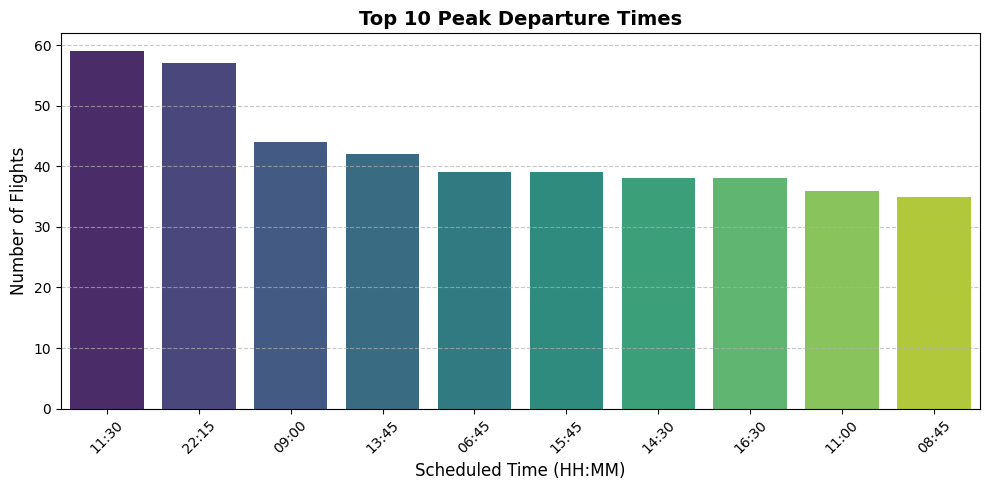

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 scheduled flight times
plt.figure(figsize=(10, 5))
top_10_times = df_clean['Time'].value_counts().head(10)

sns.barplot(x=top_10_times.index, y=top_10_times.values, palette='viridis')
plt.title('Top 10 Peak Departure Times', fontsize=14, fontweight='bold')
plt.xlabel('Scheduled Time (HH:MM)', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_29104\3862763873.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_stations.values, y=top_5_stations.index, palette='mako', orient='h')


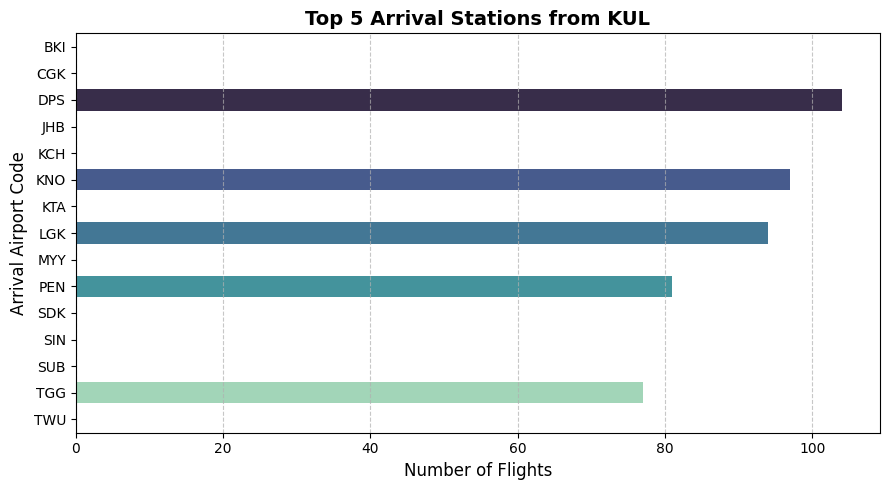

In [9]:
# Top 5 arrival airport destinations
plt.figure(figsize=(9, 5))
top_5_stations = df_clean['Arrival Station'].value_counts().head(5)

sns.barplot(x=top_5_stations.values, y=top_5_stations.index, palette='mako', orient='h')
plt.title('Top 5 Arrival Stations from KUL', fontsize=14, fontweight='bold')
plt.xlabel('Number of Flights', fontsize=12)
plt.ylabel('Arrival Airport Code', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

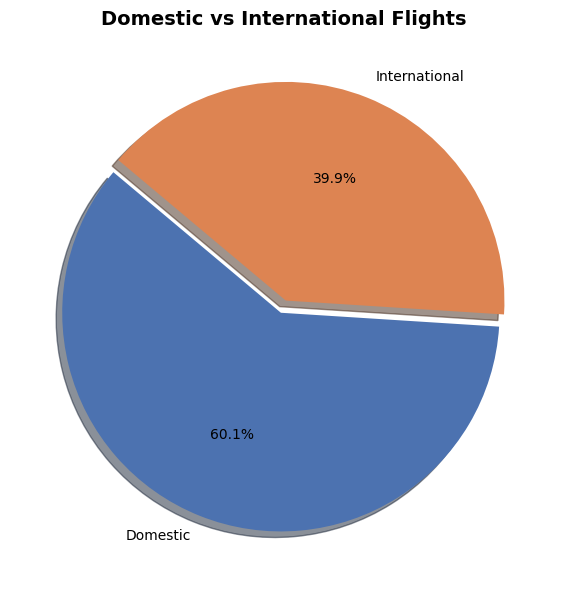

In [10]:
# Route classification distribution
plt.figure(figsize=(6, 6))
intl_counts = df_clean['InternationalDesc'].value_counts()

plt.pie(
    intl_counts, 
    labels=intl_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#4C72B0', '#DD8452'],
    explode=(0.03, 0.03),
    shadow=True
)
plt.title('Domestic vs International Flights', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

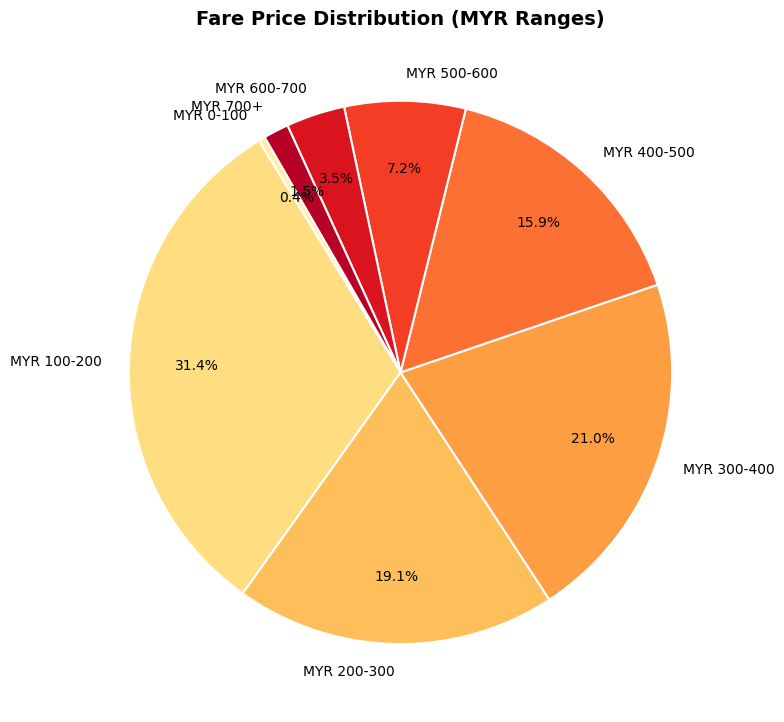

In [11]:
# Bin FarePrice into MYR 100 increments, label the ones above 700 as 'MYR 700+'
bins = [0, 100, 200, 300, 400, 500, 600, 700, np.inf]
labels = [
    'MYR 0-100', 
    'MYR 100-200', 
    'MYR 200-300', 
    'MYR 300-400', 
    'MYR 400-500', 
    'MYR 500-600', 
    'MYR 600-700', 
    'MYR 700+'
]

# Categorize fares into ranges
df_clean['Fare_Range'] = pd.cut(df_clean['FarePrice'], bins=bins, labels=labels, right=False)
fare_range_counts = df_clean['Fare_Range'].value_counts().sort_index()

# Filter out bins with zero flights for clean visual rendering
fare_range_counts = fare_range_counts[fare_range_counts > 0]

plt.figure(figsize=(8, 8))
plt.pie(
    fare_range_counts, 
    labels=fare_range_counts.index, 
    autopct='%1.1f%%', 
    startangle=120, 
    colors=sns.color_palette('YlOrRd', len(fare_range_counts)),
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Fare Price Distribution (MYR Ranges)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_29104\4084228929.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.index, y=day_counts.values, palette='Blues_d')


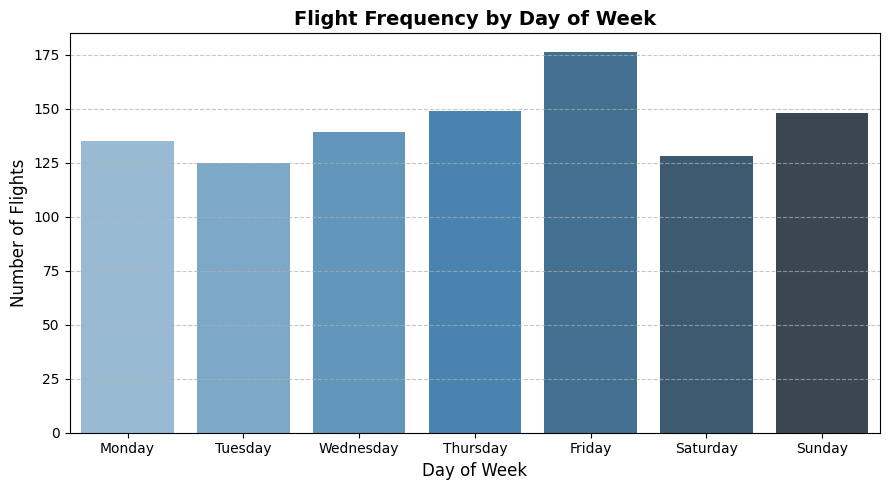

In [12]:
# Chronological order for days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df_clean['Day_of_Week'].value_counts().reindex(day_order)

plt.figure(figsize=(9, 5))
sns.barplot(x=day_counts.index, y=day_counts.values, palette='Blues_d')
plt.title('Flight Frequency by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

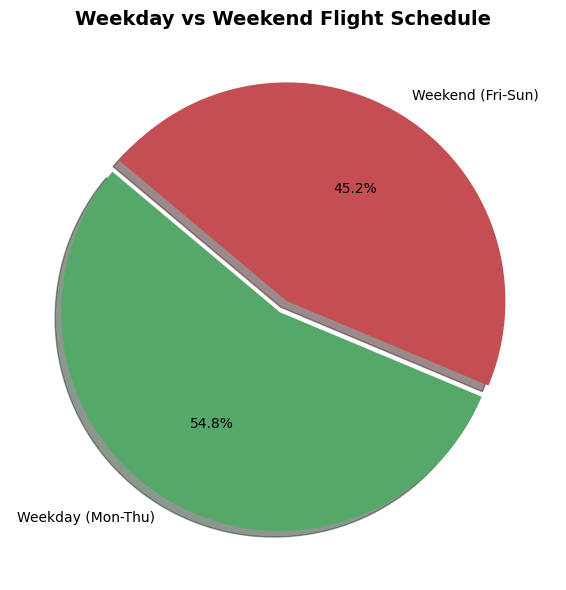

In [13]:
# Map integer binary indicator (0: Weekday, 1: Weekend) to descriptive labels
weekend_labels = df_clean['Is_Weekend'].map({0: 'Weekday (Mon-Thu)', 1: 'Weekend (Fri-Sun)'})
weekend_counts = weekend_labels.value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    weekend_counts, 
    labels=weekend_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#55A868', '#C44E52'],
    explode=(0.03, 0.03),
    shadow=True
)
plt.title('Weekday vs Weekend Flight Schedule', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Display the first 10 rows of the cleaned dataset before encoding and modeling
df_clean.head(10)

,Flight Time,Time,Flight Number,Departure Station,Arrival Station,InternationalDesc,FarePrice,Departure_Datetime,Flight_Date,Day_of_Week,Day_Code,Is_Weekend,Hour,Minute,Fare_Range
0,2026-10-01,06:45,AK 126,KUL,LGK,Domestic,131.27,2026-10-01 06:45:00,2026-10-01,Thursday,3,0,6,45,MYR 100-200
1,2026-10-01,07:15,AK 207,KUL,MYY,Domestic,223.11,2026-10-01 07:15:00,2026-10-01,Thursday,3,0,7,15,MYR 200-300
2,2026-10-01,08:45,AK 151,KUL,KTA,Domestic,150.85,2026-10-01 08:45:00,2026-10-01,Thursday,3,0,8,45,MYR 100-200
3,2026-10-01,09:00,AK 167,KUL,TGG,Domestic,125.53,2026-10-01 09:00:00,2026-10-01,Thursday,3,0,9,0,MYR 100-200
4,2026-10-01,09:00,AK 266,KUL,DPS,International,406.84,2026-10-01 09:00:00,2026-10-01,Thursday,3,0,9,0,MYR 400-500
5,2026-10-01,10:45,AK 287,KUL,KNO,International,289.96,2026-10-01 10:45:00,2026-10-01,Thursday,3,0,10,45,MYR 200-300
6,2026-10-01,11:15,AK 109,KUL,PEN,Domestic,116.52,2026-10-01 11:15:00,2026-10-01,Thursday,3,0,11,15,MYR 100-200
7,2026-10-01,11:15,AK 129,KUL,LGK,Domestic,140.16,2026-10-01 11:15:00,2026-10-01,Thursday,3,0,11,15,MYR 100-200
8,2026-10-01,11:30,AK 199,KUL,KCH,Domestic,280.32,2026-10-01 11:30:00,2026-10-01,Thursday,3,0,11,30,MYR 200-300
9,2026-10-01,12:00,AK 291,KUL,KNO,International,442.59,2026-10-01 12:00:00,2026-10-01,Thursday,3,0,12,0,MYR 400-500


**Feature Engineering & Selection**

Prompt: Flight TimeTimeFlight NumberDeparture StationArrival StationInternationalDescFarePriceDeparture_DatetimeFlight_DateDay_of_WeekDay_CodeIs_WeekendHourMinuteFare_Range02026-10-0106:45AK 126KULLGKDomestic131.272026-10-01 06:45:002026-10-01Thursday30645MYR 100-20012026-10-0107:15AK 207KULMYYDomestic223.112026-10-01 07:15:002026-10-01Thursday30715MYR 200-30022026-10-0108:45AK 151KULKTADomestic150.852026-10-01 08:45:002026-10-01Thursday30845MYR 100-20032026-10-0109:00AK 167KULTGGDomestic125.532026-10-01 09:00:002026-10-01Thursday3090MYR 100-20042026-10-0109:00AK 266KULDPSInternational406.842026-10-01 09:00:002026-10-01Thursday3090MYR 400-50052026-10-0110:45AK 287KULKNOInternational289.962026-10-01 10:45:002026-10-01Thursday301045MYR 200-30062026-10-0111:15AK 109KULPENDomestic116.522026-10-01 11:15:002026-10-01Thursday301115MYR 100-20072026-10-0111:15AK 129KULLGKDomestic140.162026-10-01 11:15:002026-10-01Thursday301115MYR 100-20082026-10-0111:30AK 199KULKCHDomestic280.322026-10-01 11:30:002026-10-01Thursday301130MYR 200-30092026-10-0112:00AK 291KULKNOInternational442.592026-10-01 12:00:002026-10-01Thursday30120MYR 400-500


This is the current data for the first 10 rows of data_clean dataframe, I want to use Flight Date, Time, Flight Number, Arrival Station, InternationalDesc, FarePrice, Days_of_Week, Is_Weekend and probably Hour as the attributes for model training and provide me the insights and predictions for the fare price. Before modeling, can you provide me some suggestions and codes on what encoding is needed and whether my features selected are good for the modeling? 


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# Step 1: Feature Engineering & Encoding
df_model = df_clean.copy()

# 1. Binary Encoding for InternationalDesc
df_model['Is_International'] = (df_model['InternationalDesc'] == 'International').astype(int)

# 2. Extract numerical Day of Month from Flight_Date
df_model['Day_of_Month'] = pd.to_datetime(df_model['Flight_Date']).dt.day

# 3. Target Encoding for Flight Number (Mean Fare per flight code)
flight_num_map = df_model.groupby('Flight Number', observed=False)['FarePrice'].mean().to_dict()
df_model['Flight_Num_Encoded'] = df_model['Flight Number'].map(flight_num_map).astype(float)

# 4. One-Hot Encoding for Arrival Station (Set dtype=int to prevent categorical type errors)
df_model = pd.get_dummies(df_model, columns=['Arrival Station'], drop_first=True, dtype=int)

# Define feature matrix (X) and target variable (y)
feature_cols = [
    'Is_International', 'Is_Weekend', 'Day_Code', 'Day_of_Month', 
    'Hour', 'Minute', 'Flight_Num_Encoded'
] + [col for col in df_model.columns if col.startswith('Arrival Station_')]

# Force all features and target to float to ensure compatibility across all model C-bindings
X = df_model[feature_cols].astype(float)
y = df_model['FarePrice'].astype(float)

In [25]:
# Step 2: Train / Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Model Building & Evaluation**

Model Building Prompt: from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

#Step 1: Feature Engineering & Encoding
df_model = df_clean.copy()

#1. Binary Encoding for InternationalDesc
df_model['Is_International'] = (df_model['InternationalDesc'] == 'International').astype(int)

#2. Extract numerical Day of Month from Flight_Date
df_model['Day_of_Month'] = pd.to_datetime(df_model['Flight_Date']).dt.day

#3. Target Encoding for Flight Number (Mean Fare per flight code)
flight_num_map = df_model.groupby('Flight Number')['FarePrice'].mean().to_dict()
df_model['Flight_Num_Encoded'] = df_model['Flight Number'].map(flight_num_map)

#4. One-Hot Encoding for Arrival Station
df_model = pd.get_dummies(df_model, columns=['Arrival Station'], drop_first=True)

#Define final feature matrix (X) and target variable (y)
feature_cols = [
    'Is_International', 'Is_Weekend', 'Day_Code', 'Day_of_Month', 
    'Hour', 'Minute', 'Flight_Num_Encoded'
] + [col for col in df_model.columns if col.startswith('Arrival Station_')]

X = df_model[feature_cols]
y = df_model['FarePrice']

Right now this is the encoding and feature selection that we have done. After the encoding, I would like to use the base regression models, XGBoost and also any suitable model that can predict the fare price for each flight routes, can you generate the code for me based on the features selected? 


In [26]:
# Step 3: Model Training & Evaluation
models = {
    'Linear Regression (Baseline)': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=42, verbose=-1)
}

results = []
predictions = {}

for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)
    
    # Predict on test set
    preds = model.predict(X_test)
    predictions[name] = preds
    
    # Calculate performance metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({
        'Model': name, 
        'MAE (MYR)': round(mae, 2), 
        'RMSE (MYR)': round(rmse, 2), 
        'R² Score': round(r2, 4)
    })

In [27]:
# Output Performance Summary Table
results_df = pd.DataFrame(results).sort_values(by='R² Score', ascending=False)
print("=== MODEL PERFORMANCE COMPARISON ===")
print(results_df.to_string(index=False))

=== MODEL PERFORMANCE COMPARISON ===
                       Model  MAE (MYR)  RMSE (MYR)  R² Score
Linear Regression (Baseline)      37.18       51.83    0.8898
               Random Forest      39.85       56.11    0.8709
                    LightGBM      39.84       56.61    0.8686
                     XGBoost      40.40       59.12    0.8567


In [28]:
# Step 4: Sample Prediction vs Actual Table
comparison_df = pd.DataFrame({
    'Actual Fare (MYR)': y_test.values,
    'XGBoost Pred': predictions['XGBoost'],
    'Random Forest Pred': predictions['Random Forest'],
    'LightGBM Pred': predictions['LightGBM'],
    'XGB Residual Error': np.abs(y_test.values - predictions['XGBoost'])
}).head(10).round(2)

print("\n=== SAMPLE TEST PREDICTIONS (FIRST 10 ROWS) ===")
print(comparison_df.to_string(index=False))


=== SAMPLE TEST PREDICTIONS (FIRST 10 ROWS) ===
 Actual Fare (MYR)  XGBoost Pred  Random Forest Pred  LightGBM Pred  XGB Residual Error
            137.29    143.389999              149.06         152.25                6.10
            374.10    427.320007              398.82         369.87               53.22
            138.73    161.389999              165.99         159.34               22.66
            151.67    124.570000              126.58         129.08               27.10
             96.45    126.629997              110.07         116.00               30.18
            487.13    420.220001              441.91         450.03               66.91
            177.59    135.300003              131.98         138.67               42.29
            212.90    160.910004              159.62         158.18               51.99
            151.31    166.949997              153.01         166.93               15.64
            109.86    105.309998              115.13         104.54    

**Prediction VS Actual Values Comparison**

Metrics to be predicted:
1. International V Domestic
2. Weekend V Weekdays
3. Hours

Prediction Test Prompt: Okay now I have successfully trained the model, I want to test three metrics for the fare prediction and compare to each models actual and predicted values:
1. International and Domestic Flight Fare
2. Weekend and Weekday Flight Fare
3. The hour fare prediction for 8 am, 12 pm, 8 pm and 12 am


In [31]:
# Step 1: Extract Test Set Predictions & Metadata
# Get original metadata for test set indices
test_indices = X_test.index
df_eval = df_clean.loc[test_indices].copy()

# Attach actual target values and model predictions
df_eval['Actual_Fare'] = y_test.values
df_eval['LR_Pred'] = predictions['Linear Regression (Baseline)']
df_eval['XGBoost_Pred'] = predictions['XGBoost']
df_eval['RF_Pred'] = predictions['Random Forest']
df_eval['LightGBM_Pred'] = predictions['LightGBM']

# Format categorical labels for reporting
df_eval['Day_Type'] = df_eval['Is_Weekend'].map({0: 'Weekday (Mon-Thu)', 1: 'Weekend (Fri-Sun)'})
df_eval['Hour_Label'] = df_eval['Hour'].map({8: '8 AM', 12: '12 PM', 20: '8 PM', 0: '12 AM'})

=== METRIC 1: INTERNATIONAL VS DOMESTIC FARES (MYR) ===
InternationalDesc  Actual_Fare  XGBoost_Pred  RF_Pred  LR_Pred  LightGBM_Pred
         Domestic       211.01    209.000000   209.26   209.48         210.26
    International       451.82    454.540009   458.90   457.91         456.15


C:\Users\HP\AppData\Local\Temp\ipykernel_29104\2522614596.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m1_df = df_eval.groupby('InternationalDesc')[['Actual_Fare', 'XGBoost_Pred', 'RF_Pred', 'LR_Pred', 'LightGBM_Pred']].mean().reset_index()


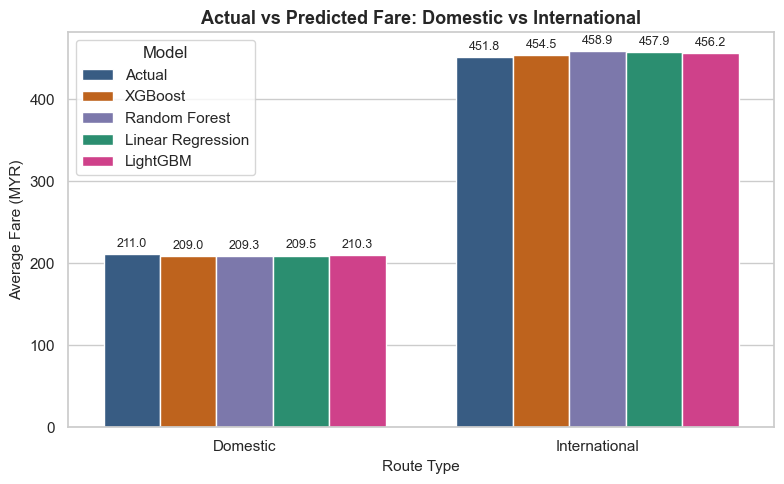

In [32]:
# Set plotting theme
sns.set_theme(style="whitegrid")
fig_palette = {'Actual': '#2b5c8f', 'XGBoost': '#d95f02', 'Random Forest': '#7570b3', 'Linear Regression': '#1b9e77', 'LightGBM': '#e7298a'}

# ---------------------------------------------------------
# Metric 1: International vs Domestic Flight Fare
# ---------------------------------------------------------
m1_df = df_eval.groupby('InternationalDesc')[['Actual_Fare', 'XGBoost_Pred', 'RF_Pred', 'LR_Pred', 'LightGBM_Pred']].mean().reset_index()
m1_melted = m1_df.melt(id_vars='InternationalDesc', 
                       var_name='Model', 
                       value_name='Mean_Fare')
m1_melted['Model'] = m1_melted['Model'].str.replace('_Pred', '').str.replace('Actual_Fare', 'Actual').str.replace('RF', 'Random Forest').str.replace('LR', 'Linear Regression').str.replace('LightGBM', 'LightGBM')

print("=== METRIC 1: INTERNATIONAL VS DOMESTIC FARES (MYR) ===")
print(m1_df.round(2).to_string(index=False))

plt.figure(figsize=(8, 5))
ax1 = sns.barplot(data=m1_melted, x='InternationalDesc', y='Mean_Fare', hue='Model', palette=fig_palette)
plt.title('Actual vs Predicted Fare: Domestic vs International', fontsize=13, fontweight='bold')
plt.xlabel('Route Type', fontsize=11)
plt.ylabel('Average Fare (MYR)', fontsize=11)
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()


=== METRIC 2: WEEKDAY VS WEEKEND FARES (MYR) ===
         Day_Type  Actual_Fare  XGBoost_Pred  RF_Pred  LR_Pred  LightGBM_Pred
Weekday (Mon-Thu)       269.12    270.540009   271.82   269.48         270.33
Weekend (Fri-Sun)       333.97    332.230011   334.54   336.28         335.12


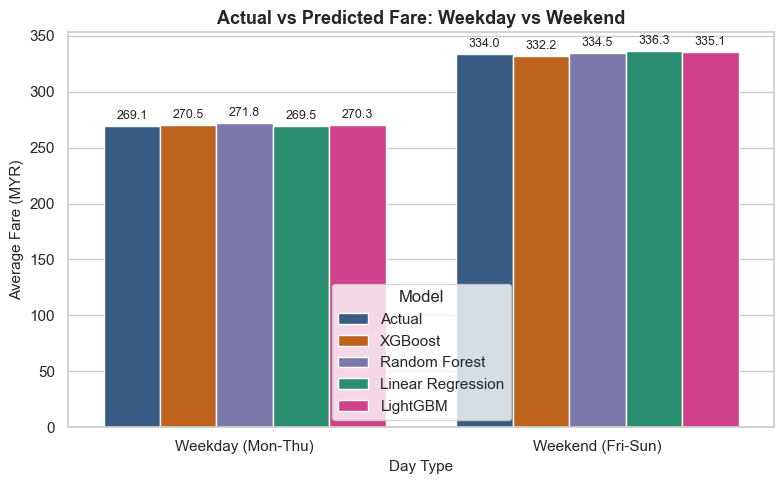

In [34]:
# ---------------------------------------------------------
# Metric 2: Weekend vs Weekday Flight Fare
# ---------------------------------------------------------
m2_df = df_eval.groupby('Day_Type')[['Actual_Fare', 'XGBoost_Pred', 'RF_Pred', 'LR_Pred', 'LightGBM_Pred']].mean().reset_index()
m2_melted = m2_df.melt(id_vars='Day_Type', 
                       var_name='Model', 
                       value_name='Mean_Fare')
m2_melted['Model'] = m2_melted['Model'].str.replace('_Pred', '').str.replace('Actual_Fare', 'Actual').str.replace('RF', 'Random Forest').str.replace('LR', 'Linear Regression').str.replace('LightGBM', 'LightGBM')

print("\n=== METRIC 2: WEEKDAY VS WEEKEND FARES (MYR) ===")
print(m2_df.round(2).to_string(index=False))

plt.figure(figsize=(8, 5))
ax2 = sns.barplot(data=m2_melted, x='Day_Type', y='Mean_Fare', hue='Model', palette=fig_palette)
plt.title('Actual vs Predicted Fare: Weekday vs Weekend', fontsize=13, fontweight='bold')
plt.xlabel('Day Type', fontsize=11)
plt.ylabel('Average Fare (MYR)', fontsize=11)
for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()


=== METRIC 3: SPECIFIC FLIGHT HOURS FARES (MYR) ===
Hour_Label  Actual_Fare  XGBoost_Pred  RF_Pred  LR_Pred  LightGBM_Pred
      8 AM       269.44    228.210007   227.44   246.92         233.50
     12 PM       404.75    403.619995   404.50   423.25         408.27
      8 PM       359.36    340.170013   346.40   358.30         348.89
     12 AM          NaN           NaN      NaN      NaN            NaN


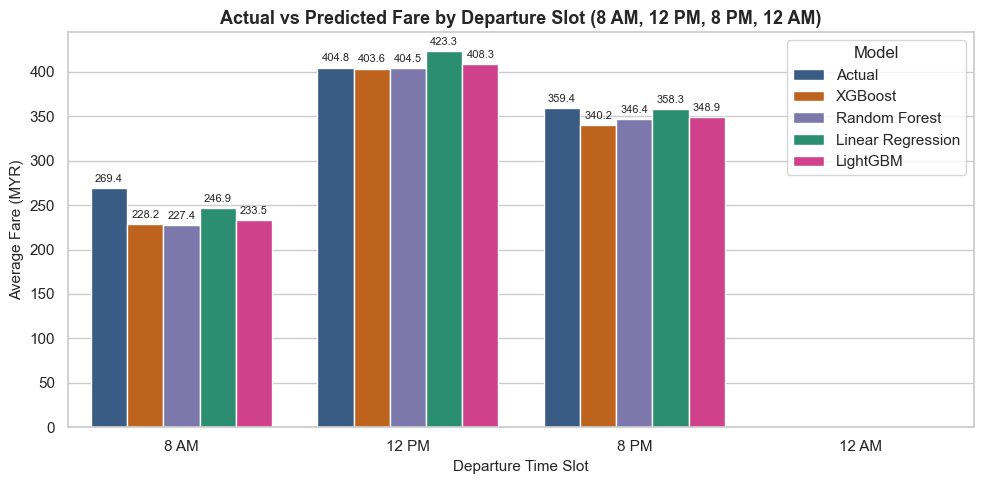

In [35]:
# ---------------------------------------------------------
# Metric 3: Specific Flight Hours (8 AM, 12 PM, 8 PM, 12 AM)
# ---------------------------------------------------------
hour_filter = [8, 12, 20, 0]
df_hours = df_eval[df_eval['Hour'].isin(hour_filter)].copy()

m3_df = df_hours.groupby('Hour_Label')[['Actual_Fare', 'XGBoost_Pred', 'RF_Pred', 'LR_Pred', 'LightGBM_Pred']].mean().reindex(['8 AM', '12 PM', '8 PM', '12 AM']).reset_index()
m3_melted = m3_df.melt(id_vars='Hour_Label', 
                       var_name='Model', 
                       value_name='Mean_Fare')
m3_melted['Model'] = m3_melted['Model'].str.replace('_Pred', '').str.replace('Actual_Fare', 'Actual').str.replace('RF', 'Random Forest').str.replace('LR', 'Linear Regression').str.replace('LightGBM', 'LightGBM')

print("\n=== METRIC 3: SPECIFIC FLIGHT HOURS FARES (MYR) ===")
print(m3_df.round(2).to_string(index=False))

plt.figure(figsize=(10, 5))
ax3 = sns.barplot(data=m3_melted, x='Hour_Label', y='Mean_Fare', hue='Model', palette=fig_palette)
plt.title('Actual vs Predicted Fare by Departure Slot (8 AM, 12 PM, 8 PM, 12 AM)', fontsize=13, fontweight='bold')
plt.xlabel('Departure Time Slot', fontsize=11)
plt.ylabel('Average Fare (MYR)', fontsize=11)
for p in ax3.patches:
    if p.get_height() > 0:
        ax3.annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=8, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()